# Análisis básico de ventanas: W00-W09

Este notebook combina los archivos procesados de los trabajadores W00 a W09 y calcula:

- Número total de ventanas y ventanas por trabajador.
- Distribución de `LOW`, `MED` y `HIGH` en conteo y porcentaje.
- Filas y celdas con valores faltantes, globalmente y por trabajador.
- Tablas y gráficos básicos.

Las categorías se normalizan a `LOW`, `MED` y `HIGH`. Si el archivo contiene `FatigueIndex` pero no una categoría, se calculan los cortes P33 y P66 sobre los valores numéricos combinados.

Raíz de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new
Salida de resultados: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs
Resumen de archivos:


,Trabajador,Archivo,Filas,Columnas
0,W00,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,104,39
1,W01,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,637,39
2,W02,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,603,39
3,W03,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,407,39
4,W04,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,562,39
5,W05,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,74,39
6,W06,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,35,39
7,W07,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,67,39
8,W08,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,133,39
9,W09,c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG...,16,39


Conjunto combinado: 2,638 filas y 39 columnas
Columna de trabajador: Trabajador
Columna de categoría detectada: None
Columna FatigueIndex detectada: FatigueIndex
Identificador de ventana detectado: UNIX Timestamp
Trabajadores encontrados: ['W00', 'W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08']
Categorías observadas: ['HIGH', 'LOW', 'MED']
P33 de FatigueIndex: -0.274580; P66: 1.587284


,Métrica,Valor
0,Filas/ventanas totales,2638
1,Filas con categoría válida,2638
2,Filas excluidas por categoría faltante/no reco...,0
3,Ventanas únicas (si existe identificador),2638


,Categoria,Ventanas,Porcentaje
0,LOW,871,33.02
1,MED,870,32.98
2,HIGH,897,34.00


...

Resumen global de filas faltantes:


,Métrica,Valor
0,Filas totales,"2,638.00"
1,Filas con al menos un valor faltante,"1,732.00"
2,Porcentaje de filas faltantes,65.66


Celdas faltantes por columna:


,Columna,Celdas_faltantes,Porcentaje_celdas
0,cambio_RMSSD,1714,64.97
1,cambio_RMSSD_z,1714,64.97
2,HR_max,1704,64.59
3,ECG_missing_peaks,1704,64.59
4,RMSSD,1704,64.59
5,cambio_HR_vs_baseline,1704,64.59
6,HR_mean,1704,64.59
7,HR_min_z,1704,64.59
8,SDNN_z,1704,64.59
9,cambio_HR_vs_baseline_z,1704,64.59


,Trabajador,Filas_totales,Filas_con_faltantes,Porcentaje_filas_faltantes
0,W00,104,1,0.96
1,W01,637,522,81.95
2,W02,603,504,83.58
3,W03,407,5,1.23
4,W04,562,517,91.99
5,W05,74,42,56.76
6,W06,35,6,17.14
7,W07,67,1,1.49
8,W08,149,134,89.93
9,W09,0,0,0.00


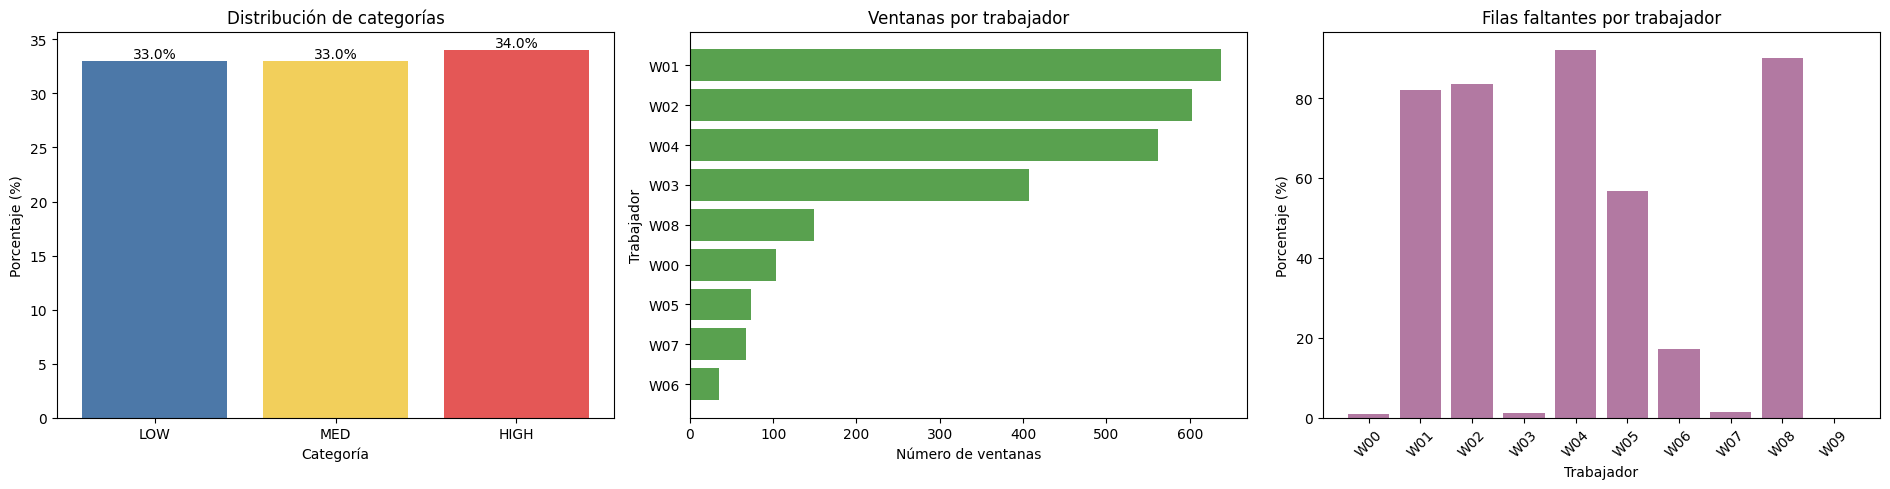

Resultados guardados en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\analysis_outputs


In [6]:
# %% [1] Cargar librerías y configurar rutas
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

EXPECTED_WORKERS = [f'W{index:02d}' for index in range(10)]
FILE_NAME = 'combined_features_1min.csv'


def find_data_root():
    """Find the folder that contains W00/PROCESSED through W09/PROCESSED."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if all((candidate / worker / 'PROCESSED' / FILE_NAME).exists() for worker in EXPECTED_WORKERS):
            return candidate
    notebook_root = Path(r'c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new')
    if all((notebook_root / worker / 'PROCESSED' / FILE_NAME).exists() for worker in EXPECTED_WORKERS):
        return notebook_root
    raise FileNotFoundError(
        'No se encontró una raíz con W00-W09/PROCESSED/combined_features_1min.csv.'
    )


DATA_ROOT = find_data_root()
OUTPUT_DIR = DATA_ROOT / 'analysis_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Raíz de datos: {DATA_ROOT}')
print(f'Salida de resultados: {OUTPUT_DIR}')

# %% [2] Leer y combinar los datos de W00-W09
worker_frames = []
file_summary_rows = []

for worker in EXPECTED_WORKERS:
    file_path = DATA_ROOT / worker / 'PROCESSED' / FILE_NAME
    if not file_path.exists():
        raise FileNotFoundError(f'Falta el archivo de {worker}: {file_path}')
    worker_frame = pd.read_csv(file_path)
    worker_frame['Worker_source'] = worker
    worker_frames.append(worker_frame)
    file_summary_rows.append({
        'Trabajador': worker,
        'Archivo': str(file_path),
        'Filas': len(worker_frame),
        'Columnas': len(worker_frame.columns),
    })

file_summary = pd.DataFrame(file_summary_rows)
data = pd.concat(worker_frames, ignore_index=True, sort=False)

print('Resumen de archivos:')
display(file_summary)
print(f'Conjunto combinado: {data.shape[0]:,} filas y {data.shape[1]:,} columnas')

# %% [3] Validar columnas, categorías y trabajadores

def find_column(columns, candidates):
    normalized = {str(column).strip().lower(): column for column in columns}
    for candidate in candidates:
        if candidate.lower() in normalized:
            return normalized[candidate.lower()]
    return None


worker_column = find_column(data.columns, ['Trabajador', 'worker', 'worker_id', 'Worker_source'])
if worker_column is None:
    data['Trabajador'] = data['Worker_source']
    worker_column = 'Trabajador'
else:
    data['Trabajador'] = data[worker_column].fillna(data['Worker_source']).astype(str).str.upper()

category_column = find_column(
    data.columns,
    ['Category', 'Categoria', 'Categoría', 'FatigueCategory', 'fatigue_category', 'label', 'target'],
)
fatigue_column = find_column(data.columns, ['FatigueIndex', 'fatigue_index', 'fatigue'])
window_column = find_column(
    data.columns,
    ['WindowID', 'window_id', 'Ventana', 'ventana_id', 'UNIX Timestamp', 'timestamp'],
)

print(f'Columna de trabajador: {worker_column}')
print(f'Columna de categoría detectada: {category_column}')
print(f'Columna FatigueIndex detectada: {fatigue_column}')
print(f'Identificador de ventana detectado: {window_column}')
print('Trabajadores encontrados:', sorted(data['Trabajador'].dropna().unique()))

unexpected_workers = sorted(set(data['Trabajador'].dropna().unique()) - set(EXPECTED_WORKERS))
if unexpected_workers:
    print('Aviso: trabajadores fuera de W00-W09:', unexpected_workers)

# Mantener una copia de los datos originales para el análisis de valores faltantes.
original_columns = list(data.columns)
raw_missing_mask = data[original_columns].isna()

# Normalizar una categoría existente; si no existe, se calcula desde FatigueIndex.
def normalize_category(value):
    if pd.isna(value):
        return np.nan
    normalized = re.sub(r'[^a-z]', '', str(value).lower())
    mapping = {
        'low': 'LOW', 'bajo': 'LOW', 'baja': 'LOW',
        'med': 'MED', 'medium': 'MED', 'medio': 'MED', 'media': 'MED',
        'high': 'HIGH', 'hithg': 'HIGH', 'alto': 'HIGH', 'alta': 'HIGH',
    }
    return mapping.get(normalized, np.nan)


if category_column is not None:
    data['Categoria'] = data[category_column].map(normalize_category)
    unexpected_categories = sorted(
        data.loc[data[category_column].notna() & data['Categoria'].isna(), category_column]
        .astype(str).unique()
    )
    p33 = np.nan
    p66 = np.nan
else:
    if fatigue_column is None:
        raise ValueError('No se encontró una columna de categoría ni FatigueIndex.')
    numeric_fatigue = pd.to_numeric(data[fatigue_column], errors='coerce')
    p33 = numeric_fatigue.quantile(0.33)
    p66 = numeric_fatigue.quantile(0.66)
    data['Categoria'] = pd.cut(
        numeric_fatigue,
        bins=[-np.inf, p33, p66, np.inf],
        labels=['LOW', 'MED', 'HIGH'],
        right=False,
    ).astype(object)
    unexpected_categories = []

print('Categorías observadas:', sorted(data['Categoria'].dropna().unique()))
if unexpected_categories:
    print('Aviso: categorías no reconocidas, tratadas como faltantes:', unexpected_categories)
if pd.notna(p33):
    print(f'P33 de FatigueIndex: {p33:.6f}; P66: {p66:.6f}')

# %% [4] Calcular el número total de ventanas
raw_row_count = len(data)
valid_category_count = data['Categoria'].notna().sum()
unique_window_count = data[window_column].nunique(dropna=True) if window_column else np.nan
window_count_summary = pd.DataFrame({
    'Métrica': [
        'Filas/ventanas totales',
        'Filas con categoría válida',
        'Filas excluidas por categoría faltante/no reconocida',
        'Ventanas únicas (si existe identificador)',
    ],
    'Valor': [raw_row_count, valid_category_count, raw_row_count - valid_category_count, unique_window_count],
})
display(window_count_summary)

# %% [5] Distribución porcentual por categoría: LOW, MED y HIGH
category_order = ['LOW', 'MED', 'HIGH']
category_distribution = (
    data.loc[data['Categoria'].notna(), 'Categoria']
    .value_counts()
    .reindex(category_order, fill_value=0)
    .rename_axis('Categoria')
    .reset_index(name='Ventanas')
)
category_distribution['Porcentaje'] = (
    category_distribution['Ventanas'] / valid_category_count * 100
    if valid_category_count else 0
)
display(category_distribution)

# %% [6] Distribución porcentual de ventanas por trabajador
worker_distribution = (
    data.groupby('Trabajador', dropna=False)
    .size()
    .rename('Ventanas')
    .reset_index()
)
worker_distribution['Porcentaje_total'] = worker_distribution['Ventanas'] / raw_row_count * 100
worker_distribution = worker_distribution.sort_values('Ventanas', ascending=False).reset_index(drop=True)
display(worker_distribution)

worker_category_distribution = pd.crosstab(
    data['Trabajador'],
    data['Categoria'],
).reindex(columns=category_order, fill_value=0)
worker_category_distribution['Total_validas'] = worker_category_distribution.sum(axis=1)
for category in category_order:
    worker_category_distribution[f'{category}_porcentaje'] = (
        worker_category_distribution[category]
        .div(worker_category_distribution['Total_validas'].replace(0, np.nan))
        .mul(100)
        .fillna(0)
    )
worker_category_distribution = worker_category_distribution.reset_index()
display(worker_category_distribution)

# %% [7] Filas con valores faltantes: total
row_missing_mask = raw_missing_mask.any(axis=1)
missing_row_count = int(row_missing_mask.sum())
missing_row_percentage = missing_row_count / raw_row_count * 100 if raw_row_count else 0
missing_by_column = pd.DataFrame({
    'Columna': original_columns,
    'Celdas_faltantes': raw_missing_mask.sum().values,
})
missing_by_column['Porcentaje_celdas'] = missing_by_column['Celdas_faltantes'] / raw_row_count * 100
missing_by_column = missing_by_column.sort_values('Celdas_faltantes', ascending=False).reset_index(drop=True)
missing_summary = pd.DataFrame({
    'Métrica': ['Filas totales', 'Filas con al menos un valor faltante', 'Porcentaje de filas faltantes'],
    'Valor': [raw_row_count, missing_row_count, missing_row_percentage],
})
print('Resumen global de filas faltantes:')
display(missing_summary)
print('Celdas faltantes por columna:')
display(missing_by_column)

# %% [8] Filas con valores faltantes por trabajador
missing_by_worker = (
    data.assign(_fila_con_faltantes=row_missing_mask)
    .groupby('Trabajador', dropna=False)
    .agg(
        Filas_totales=('Trabajador', 'size'),
        Filas_con_faltantes=('_fila_con_faltantes', 'sum'),
    )
    .reindex(EXPECTED_WORKERS, fill_value=0)
    .reset_index()
)
missing_by_worker['Porcentaje_filas_faltantes'] = (
    missing_by_worker['Filas_con_faltantes']
    .div(missing_by_worker['Filas_totales'].replace(0, np.nan))
    .mul(100)
    .fillna(0)
)
display(missing_by_worker)

# %% [9] Mostrar tablas, gráficos y guardar resultados
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].bar(category_distribution['Categoria'], category_distribution['Porcentaje'], color=['#4C78A8', '#F2CF5B', '#E45756'])
axes[0].set_title('Distribución de categorías')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Porcentaje (%)')
for index, value in enumerate(category_distribution['Porcentaje']):
    axes[0].text(index, value, f'{value:.1f}%', ha='center', va='bottom')

worker_plot = worker_distribution.sort_values('Ventanas')
axes[1].barh(worker_plot['Trabajador'], worker_plot['Ventanas'], color='#59A14F')
axes[1].set_title('Ventanas por trabajador')
axes[1].set_xlabel('Número de ventanas')
axes[1].set_ylabel('Trabajador')

axes[2].bar(missing_by_worker['Trabajador'], missing_by_worker['Porcentaje_filas_faltantes'], color='#B279A2')
axes[2].set_title('Filas faltantes por trabajador')
axes[2].set_xlabel('Trabajador')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

file_summary.to_csv(OUTPUT_DIR / 'resumen_archivos.csv', index=False)
window_count_summary.to_csv(OUTPUT_DIR / 'resumen_numero_ventanas.csv', index=False)
category_distribution.to_csv(OUTPUT_DIR / 'distribucion_categorias.csv', index=False)
worker_distribution.to_csv(OUTPUT_DIR / 'distribucion_por_trabajador.csv', index=False)
worker_category_distribution.to_csv(OUTPUT_DIR / 'distribucion_categoria_por_trabajador.csv', index=False)
missing_summary.to_csv(OUTPUT_DIR / 'resumen_faltantes_global.csv', index=False)
missing_by_column.to_csv(OUTPUT_DIR / 'faltantes_por_columna.csv', index=False)
missing_by_worker.to_csv(OUTPUT_DIR / 'faltantes_por_trabajador.csv', index=False)

print(f'Resultados guardados en: {OUTPUT_DIR}')

## Comparación manual de los modelos

Estas tres tablas resumen las medias disponibles de los experimentos A, B y C para Logistic Regression, Random Forest, SVM y XGBoost. Los valores `NaN` indican métricas que no estaban calculadas en las salidas guardadas de ese experimento.

In [7]:
# Tabla 1: Experimento A - ECG + HR/RR + temporales
summary_A = pd.DataFrame([
    ['Logistic Regression', 0.874911, 0.658637, 0.694129, 0.781666, 0.742559, 0.700735],
    ['Random Forest',       0.899995, 0.700722, 0.886433, 0.861602, 0.829050, 0.803927],
    ['SVM',                 0.810810, 0.650470, 0.878534, 0.805507, 0.779938, 0.731079],
    ['XGBoost',             0.906677, 0.741004, 0.916549, 0.881704, 0.854743, 0.831049],
], columns=[
    'Modelo',
    'Recall_Low',
    'Recall_Medium',
    'Recall_High',
    'Accuracy',
    'Balanced_Accuracy',
    'Macro_F1',
])

summary_A = summary_A.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(summary_A.round(4))

,Modelo,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,XGBoost,0.91,0.74,0.92,0.88,0.85,0.83
1,Random Forest,0.90,0.70,0.89,0.86,0.83,0.80
2,SVM,0.81,0.65,0.88,0.81,0.78,0.73
3,Logistic Regression,0.87,0.66,0.69,0.78,0.74,0.70


In [8]:
# Tabla 2: Experimento B - HR/RR + temporales
summary_B = pd.DataFrame([
    ['Logistic Regression', np.nan, np.nan, np.nan, 0.564700, 0.530900, 0.470900],
    ['Random Forest',       np.nan, np.nan, np.nan, 0.661900, 0.643600, 0.604500],
    ['SVM',                 np.nan, np.nan, np.nan, 0.621000, 0.621300, 0.556900],
    ['XGBoost',             np.nan, np.nan, np.nan, 0.656600, 0.641300, 0.599100],
], columns=[
    'Modelo',
    'Recall_Low',
    'Recall_Medium',
    'Recall_High',
    'Accuracy',
    'Balanced_Accuracy',
    'Macro_F1',
])

summary_B = summary_B.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(summary_B.round(4))

,Modelo,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,Random Forest,NaN,NaN,NaN,0.66,0.64,0.60
1,XGBoost,NaN,NaN,NaN,0.66,0.64,0.60
2,SVM,NaN,NaN,NaN,0.62,0.62,0.56
3,Logistic Regression,NaN,NaN,NaN,0.56,0.53,0.47


In [9]:
# Tabla 3: Experimento C - ECG
summary_C = pd.DataFrame([
    ['Logistic Regression', np.nan, np.nan, np.nan, 0.597400, 0.536900, 0.501200],
    ['Random Forest',       np.nan, np.nan, np.nan, 0.663600, 0.607300, 0.572800],
    ['SVM',                 np.nan, np.nan, np.nan, 0.613300, 0.574900, 0.529600],
    ['XGBoost',             np.nan, np.nan, np.nan, 0.678300, 0.613600, 0.589200],
], columns=[
    'Modelo',
    'Recall_Low',
    'Recall_Medium',
    'Recall_High',
    'Accuracy',
    'Balanced_Accuracy',
    'Macro_F1',
])

summary_C = summary_C.sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(summary_C.round(4))

,Modelo,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,XGBoost,NaN,NaN,NaN,0.68,0.61,0.59
1,Random Forest,NaN,NaN,NaN,0.66,0.61,0.57
2,SVM,NaN,NaN,NaN,0.61,0.57,0.53
3,Logistic Regression,NaN,NaN,NaN,0.60,0.54,0.50
